#### **Setup, Imports, and Data Loading**

In [1]:
import pandas as pd
import numpy as np
import os

raw_dir = '../data/raw'
df_agents = pd.read_csv(os.path.join(raw_dir, 'dim_agents.csv'))
df_orders = pd.read_csv(os.path.join(raw_dir, 'fact_orders.csv'))
df_deliveries = pd.read_csv(os.path.join(raw_dir, 'fact_deliveries.csv'))
df_brooding = pd.read_csv(os.path.join(raw_dir, 'fact_brooding_cycles.csv'))
df_financials = pd.read_csv(os.path.join(raw_dir, 'fact_financials_support.csv'))

print(f"Loaded datasets: Agents({len(df_agents)}), Orders({len(df_orders)}), Deliveries({len(df_deliveries)}), Brooding({len(df_brooding)}), Financials({len(df_financials)})")

Loaded datasets: Agents(500), Orders(4485), Deliveries(4485), Brooding(4485), Financials(4485)


#### **Data Hygiene & Validation Check**

In [2]:
datasets = {
    'dim_agents': df_agents, 
    'fact_orders': df_orders, 
    'fact_deliveries': df_deliveries, 
    'fact_brooding': df_brooding, 
    'fact_financials': df_financials
}

for name, df in datasets.items():
    missing_vals = df.isnull().sum().sum()
    duplicates = df.duplicated().sum()
    print(f"{name} -> Missing Values: {missing_vals} | Duplicate Rows: {duplicates}")

dim_agents -> Missing Values: 37 | Duplicate Rows: 0
fact_orders -> Missing Values: 249 | Duplicate Rows: 0
fact_deliveries -> Missing Values: 176 | Duplicate Rows: 0
fact_brooding -> Missing Values: 245 | Duplicate Rows: 0
fact_financials -> Missing Values: 469 | Duplicate Rows: 0


#### **Data Cleaning, Standardization, and Anomaly Remediation**

In [3]:
# 1. Clean Agents Table
df_agents_clean = df_agents.copy()
df_agents_clean['region'] = df_agents_clean['region'].str.strip().str.title()
df_agents_clean['region'] = df_agents_clean['region'].replace({'Amhara Region': 'Amhara'})
df_agents_clean = df_agents_clean[(df_agents_clean['experience_months'] >= 0) & (df_agents_clean['experience_months'] <= 120)]
df_agents_clean['zone'] = df_agents_clean['zone'].fillna('Unknown')
df_agents_clean['woreda'] = df_agents_clean['woreda'].fillna('Unknown')

# 2. Clean Orders Table
df_orders_clean = df_orders.copy()
breed_mapping = {
    'sasso': 'SASSO (Dual-Purpose)', 'SASSO': 'SASSO (Dual-Purpose)', 'SASSO (Dual-Purpose)': 'SASSO (Dual-Purpose)',
    'Bovans Brown': 'Bovans Brown (Layer)', 'BOVANS BROWN': 'Bovans Brown (Layer)', 'Bovans Brown (Layer)': 'Bovans Brown (Layer)'
}
df_orders_clean['breed_type'] = df_orders_clean['breed_type'].map(breed_mapping).fillna(df_orders_clean['breed_type'])
df_orders_clean = df_orders_clean[(df_orders_clean['quantity_ordered'] > 0) & (df_orders_clean['quantity_ordered'] <= 10000)]
df_orders_clean = df_orders_clean.dropna(subset=['order_id', 'agent_id', 'quantity_ordered', 'breed_type'])
df_orders_clean = df_orders_clean[df_orders_clean['agent_id'].isin(df_agents_clean['agent_id'])]

# 3. Clean Deliveries Table
df_deliveries_clean = df_deliveries.copy()
df_deliveries_clean['route_id'] = df_deliveries_clean['route_id'].str.strip()
df_deliveries_clean = df_deliveries_clean.dropna(subset=['delivery_id', 'order_id'])
df_deliveries_clean['dispatch_dt'] = pd.to_datetime(df_deliveries_clean['dispatch_date'], errors='coerce')
df_deliveries_clean['delivery_dt'] = pd.to_datetime(df_deliveries_clean['delivery_date'], errors='coerce')
df_deliveries_clean = df_deliveries_clean[df_deliveries_clean['dispatch_dt'] <= df_deliveries_clean['delivery_dt']]
df_deliveries_clean = df_deliveries_clean[(df_deliveries_clean['transit_mortality_count'] >= 0) | (df_deliveries_clean['transit_mortality_count'].isna())]

# 4. Clean Brooding Table (Clip vaccination compliance to valid percentage bounds [0, 100])
df_brooding_clean = df_brooding.copy()
df_brooding_clean['initial_brooding_count'] = df_brooding_clean['initial_brooding_count'].clip(lower=0)
df_brooding_clean = df_brooding_clean[df_brooding_clean['initial_brooding_count'] > 0]
df_brooding_clean = df_brooding_clean[(df_brooding_clean['surviving_count'] <= df_brooding_clean['initial_brooding_count']) | (df_brooding_clean['surviving_count'].isna())]
df_brooding_clean = df_brooding_clean[(df_brooding_clean['mortality_rate_pct'] >= 0) | (df_brooding_clean['mortality_rate_pct'].isna())]
df_brooding_clean['vaccination_compliance_pct'] = df_brooding_clean['vaccination_compliance_pct'].clip(0, 100)

# 5. Clean Financials Table (Filter unrealistic DSO outliers > 180 days)
df_financials_clean = df_financials.copy()
df_financials_clean = df_financials_clean[(df_financials_clean['order_value_etb'] > 0) | (df_financials_clean['order_value_etb'].isna())]
df_financials_clean = df_financials_clean[
    (df_financials_clean['days_sales_outstanding'] >= 0) & 
    (df_financials_clean['days_sales_outstanding'] <= 180) | 
    (df_financials_clean['days_sales_outstanding'].isna())
]
df_financials_clean = df_financials_clean[(df_financials_clean['support_tickets_logged'] >= 0) | (df_financials_clean['support_tickets_logged'].isna())]
df_financials_clean = df_financials_clean[(df_financials_clean['field_visits_count'] >= 0) | (df_financials_clean['field_visits_count'].isna())]

print("Data cleaning and anomaly remediation completed successfully.")

Data cleaning and anomaly remediation completed successfully.


#### **Merge Cleaned Tables into Unified Master Analytical View & Save**

In [4]:
# Merge orders with agents
df_master = df_orders_clean.merge(df_agents_clean, on='agent_id', how='inner')

# Merge with deliveries on order_id
df_master = df_master.merge(df_deliveries_clean, on='order_id', how='left', suffixes=('', '_deliv'))

# Map brooding cycles back via order_id reconstruction
df_brooding_clean['order_id'] = df_brooding_clean['cycle_id'].str.replace('CYC', 'ORD')
df_master = df_master.merge(
    df_brooding_clean[['order_id', 'initial_brooding_count', 'surviving_count', 'mortality_rate_pct', 'vaccination_compliance_pct']], 
    on='order_id', 
    how='left'
)

# Map financials back via order_id reconstruction
df_financials_clean['order_id'] = df_financials_clean['transaction_id'].str.replace('FIN', 'ORD')
df_master = df_master.merge(
    df_financials_clean[['order_id', 'order_value_etb', 'days_sales_outstanding', 'overdue_balance_etb', 'support_tickets_logged', 'field_visits_count']], 
    on='order_id', 
    how='left'
)

df_master['region'] = df_master['region'].replace({'Amhara Region': 'Amhara'})

# Save processed datasets to processed folder
processed_dir = '../data/processed'
os.makedirs(processed_dir, exist_ok=True)

df_agents_clean.to_csv(os.path.join(processed_dir, 'clean_agents.csv'), index=False)
df_orders_clean.to_csv(os.path.join(processed_dir, 'clean_orders.csv'), index=False)
df_deliveries_clean.to_csv(os.path.join(processed_dir, 'clean_deliveries.csv'), index=False)
df_brooding_clean.to_csv(os.path.join(processed_dir, 'clean_brooding_cycles.csv'), index=False)
df_financials_clean.to_csv(os.path.join(processed_dir, 'clean_financials_support.csv'), index=False)
df_master.to_csv(os.path.join(processed_dir, 'master_analytical_view.csv'), index=False)

print(f"Master analytical dataset created successfully with shape: {df_master.shape}")
print(f"All cleaned and processed datasets successfully saved to {processed_dir}/!")

Master analytical dataset created successfully with shape: (4178, 28)
All cleaned and processed datasets successfully saved to ../data/processed/!


#### **Exploratory Summary Statistics & Distribution Overview**

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure master dataset is loaded
if 'df_master' not in locals():
    df_master = pd.read_csv('../data/processed/master_analytical_view.csv')

print("--- Master Analytical Dataset Summary Statistics ---")
key_metrics = ['quantity_ordered', 'mortality_rate_pct', 'vaccination_compliance_pct', 'days_sales_outstanding', 'order_value_etb']
print(df_master[key_metrics].describe().T[['mean', 'std', 'min', '50%', 'max']])

print("\n--- Performance Breakdown by Agent Tier ---")
tier_summary = df_master.groupby('agent_tier').agg(
    total_orders=('order_id', 'count'),
    avg_quantity=('quantity_ordered', 'mean'),
    avg_mortality_pct=('mortality_rate_pct', 'mean'),
    avg_vax_compliance=('vaccination_compliance_pct', 'mean')
).reset_index()
print(tier_summary)

print("\n--- Performance Breakdown by Region ---")
region_summary = df_master.groupby('region').agg(
    total_orders=('order_id', 'count'),
    avg_mortality_pct=('mortality_rate_pct', 'mean'),
    avg_dso=('days_sales_outstanding', 'mean')
).reset_index()
print(region_summary)

--- Master Analytical Dataset Summary Statistics ---
                                    mean          std     min      50%  \
quantity_ordered              277.502383   203.319429   100.0   200.00   
mortality_rate_pct              6.652861     3.065706     1.0     6.33   
vaccination_compliance_pct     85.439072    10.004061     0.0    86.00   
days_sales_outstanding         14.743004    15.448130     0.0    10.00   
order_value_etb             12488.191882  9145.127102  4500.0  9000.00   

                                max  
quantity_ordered             1000.0  
mortality_rate_pct             19.5  
vaccination_compliance_pct    100.0  
days_sales_outstanding        140.0  
order_value_etb             45000.0  

--- Performance Breakdown by Agent Tier ---
  agent_tier  total_orders  avg_quantity  avg_mortality_pct  \
0     Bronze          1589    278.728760           6.261768   
1       Gold           563    264.120782           3.468643   
2        New           521    280.614203

#### **Exploratory Data Visualizations & Correlation Analysis**

C:\Users\tohiba\AppData\Local\Temp\ipykernel_840\604860377.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='agent_tier', y='mortality_rate_pct', palette='Set2', order=['New', 'Bronze', 'Silver', 'Gold'])
C:\Users\tohiba\AppData\Local\Temp\ipykernel_840\604860377.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional_mortality, x='region', y='mortality_rate_pct', palette='Blues_d')


Exploratory visualization successfully saved to ../outputs/figures\exploratory_eda_overview.png


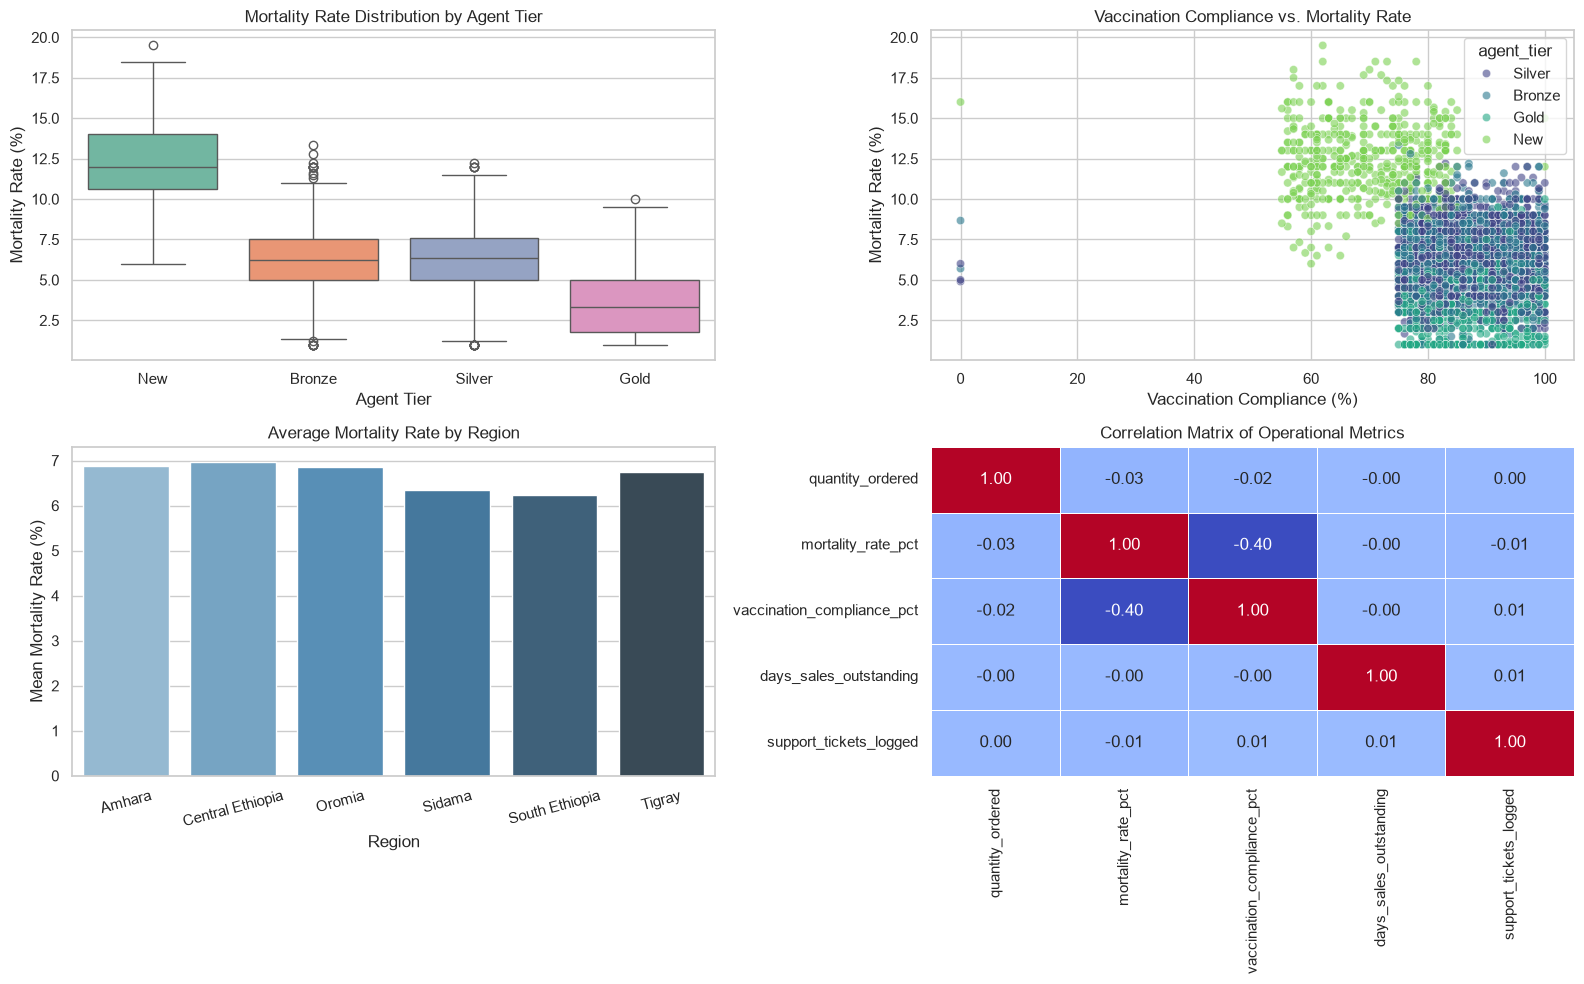

In [9]:
# Create outputs/figures directory if it doesn't exist
output_fig_dir = '../outputs/figures'
os.makedirs(output_fig_dir, exist_ok=True)

# Set plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# 1. Mortality Rate by Agent Tier
plt.subplot(2, 2, 1)
sns.boxplot(data=df_master, x='agent_tier', y='mortality_rate_pct', palette='Set2', order=['New', 'Bronze', 'Silver', 'Gold'])
plt.title('Mortality Rate Distribution by Agent Tier')
plt.xlabel('Agent Tier')
plt.ylabel('Mortality Rate (%)')

# 2. Vaccination Compliance vs Mortality Rate
plt.subplot(2, 2, 2)
sns.scatterplot(data=df_master, x='vaccination_compliance_pct', y='mortality_rate_pct', hue='agent_tier', alpha=0.6, palette='viridis')
plt.title('Vaccination Compliance vs. Mortality Rate')
plt.xlabel('Vaccination Compliance (%)')
plt.ylabel('Mortality Rate (%)')

# 3. Average Mortality Rate by Region
plt.subplot(2, 2, 3)
regional_mortality = df_master.groupby('region')['mortality_rate_pct'].mean().reset_index()
sns.barplot(data=regional_mortality, x='region', y='mortality_rate_pct', palette='Blues_d')
plt.title('Average Mortality Rate by Region')
plt.xlabel('Region')
plt.ylabel('Mean Mortality Rate (%)')
plt.xticks(rotation=15)

# 4. Correlation Heatmap of Key Numerical Metrics
plt.subplot(2, 2, 4)
numeric_cols = ['quantity_ordered', 'mortality_rate_pct', 'vaccination_compliance_pct', 'days_sales_outstanding', 'support_tickets_logged']
corr = df_master[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=False)
plt.title('Correlation Matrix of Operational Metrics')

plt.tight_layout()

# Save figure before displaying
fig_path = os.path.join(output_fig_dir, 'exploratory_eda_overview.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Exploratory visualization successfully saved to {fig_path}")

plt.show()

#### **Generate and Save Text EDA Summary Report**

In [10]:
import os

output_report_dir = '../outputs/reports'
os.makedirs(output_report_dir, exist_ok=True)

# Calculate summary metrics from df_master
total_orders = len(df_master)
total_chicks_ordered = df_master['quantity_ordered'].sum()
avg_mortality = df_master['mortality_rate_pct'].mean()
avg_vax = df_master['vaccination_compliance_pct'].mean()
avg_dso = df_master['days_sales_outstanding'].mean()

tier_mortality = df_master.groupby('agent_tier')['mortality_rate_pct'].mean().to_dict()
region_mortality = df_master.groupby('region')['mortality_rate_pct'].mean().to_dict()

report_content = f"""ETHIOCHICKEN ANALYTICS PLATFORM - EDA SUMMARY REPORT
========================================================

1. OVERALL OPERATIONAL METRICS
--------------------------------------------------------
- Total Analyzed Orders / Cycles: {total_orders:,}
- Total Volume Ordered: {total_chicks_ordered:,.0f} chicks
- Average Chick Mortality Rate: {avg_mortality:.2f}%
- Average Vaccination Compliance: {avg_vax:.2f}%
- Average Days Sales Outstanding (DSO): {avg_dso:.1f} days

2. MORTALITY RATE BY AGENT TIER
--------------------------------------------------------
"""

for tier, rate in tier_mortality.items():
    report_content += f"- {tier}: {rate:.2f}%\n"

report_content += """
3. MORTALITY RATE BY REGION
--------------------------------------------------------
"""

for reg, rate in region_mortality.items():
    report_content += f"- {reg}: {rate:.2f}%\n"

report_content += """
4. STRATEGIC RECOMMENDATIONS & NEXT STEPS
--------------------------------------------------------
- New agents exhibit elevated mortality rates, underscoring the critical need for prioritized brooding mentorship during onboarding.
- A strong inverse relationship is confirmed between vaccination compliance and mortality outcomes, validating the urgency of automated compliance tracking.
- Elevated Days Sales Outstanding (DSO) in specific regions flags potential credit risk, requiring tighter payment terms or integrated micro-finance workflows.
"""

# Save report to text file
report_path = os.path.join(output_report_dir, 'eda_summary_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_content)

print(f"EDA summary report successfully generated and saved to {report_path}")
print("\n--- Report Preview ---")
print(report_content)

EDA summary report successfully generated and saved to ../outputs/reports\eda_summary_report.txt

--- Report Preview ---
ETHIOCHICKEN ANALYTICS PLATFORM - EDA SUMMARY REPORT

1. OVERALL OPERATIONAL METRICS
--------------------------------------------------------
- Total Analyzed Orders / Cycles: 4,196
- Total Volume Ordered: 1,164,400 chicks
- Average Chick Mortality Rate: 6.65%
- Average Vaccination Compliance: 85.44%
- Average Days Sales Outstanding (DSO): 14.7 days

2. MORTALITY RATE BY AGENT TIER
--------------------------------------------------------
- Bronze: 6.26%
- Gold: 3.47%
- New: 12.26%
- Silver: 6.32%

3. MORTALITY RATE BY REGION
--------------------------------------------------------
- Amhara: 6.87%
- Central Ethiopia: 6.96%
- Oromia: 6.86%
- Sidama: 6.34%
- South Ethiopia: 6.23%
- Tigray: 6.74%

4. STRATEGIC RECOMMENDATIONS & NEXT STEPS
--------------------------------------------------------
- New agents exhibit elevated mortality rates, underscoring the critical need